# Build a language: giving Danish and Dutch a meaning dictionary, automatically

This notebook is the public companion to our paper on building **semantic lexicons** for
Danish and Dutch by automatic translation. It retells the paper in plain language,
redraws every figure from the published results file, and ends with the recommended,
fully open-source recipe for adding your own language today.

**Who this is for.** Anyone curious about how it was done. No programming or linguistics
background needed: the text cells explain everything, and the code cells only draw
pictures.

**How to run it.** The notebook starts in `MODE = "PRECOMPUTED"` (the default): every
cell runs offline in seconds, costs nothing, and calls no AI services. All numbers are
loaded from `results_index.json`, which sits next to this notebook and records, for
every number, the measurement file it came from. Rebuilding everything from scratch
(`MODE = "LIVE"`) is documented in `build_your_language.ipynb` / `lexicon_pipeline/`; the real commands are quoted
below in clearly marked boxes but never executed here.

**Small glossary** (each term is explained again when it first matters):

| Term | Plain meaning |
| --- | --- |
| **USAS** | a dictionary of ~230 meaning categories like "Medicine" or "Money" |
| **Lexicon** | a word list where each word carries its possible meaning tags |
| **Tagger** | software that reads text and picks one meaning tag per word |
| **Coverage** | the share of words in a text that the dictionary knows |
| **Accuracy** | the share of words it tags correctly |
| **Compound** | one word glued together from smaller words (Danish loves these) |

*(You can run the next cell without reading it - it loads the results file and sets the
figure style.)*

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches

# PRECOMPUTED (default): every cell below runs offline in seconds and costs nothing.
# 'LIVE' is documented in ../evals/REPRODUCE.md; its commands are quoted further down
# in clearly marked boxes - this notebook never executes them.
MODE = 'PRECOMPUTED'

INDEX = json.loads(Path('results_index.json').read_text(encoding='utf-8'))

# Figure style: light theme, direct value labels, one axis per chart.
SURFACE, INK, MUTED = '#fcfcfb', '#0b0b0b', '#52514e'
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4'
mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'text.color': INK, 'axes.titlecolor': INK, 'axes.edgecolor': MUTED,
    'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10.5, 'axes.titlesize': 12.5, 'figure.dpi': 110,
})

def label_bars(ax, bars, fmt='{:.1f}', fs=9):
    '''Write the value on every bar (the lighter palette colors need this).'''
    for b in bars:
        ax.annotate(fmt.format(b.get_height()),
                    (b.get_x() + b.get_width() / 2, b.get_height()),
                    xytext=(0, 2.5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=fs, color=INK)

def show_source(*sources):
    '''Provenance line printed under each figure: where the numbers were measured.'''
    print('numbers loaded from results_index.json <-', '; '.join(sources))

print('results_index.json compiled:', INDEX['compiled_utc'])
print('scoring protocol:', INDEX['protocol'])
print('MODE =', MODE, '- nothing is recomputed, no API calls, no GPU')

results_index.json compiled: 2026-09-04T10:12:08.816372+00:00
scoring protocol: exact top-1, labelled non-punctuation tokens (*_np refs)
MODE = PRECOMPUTED - nothing is recomputed, no API calls, no GPU


## The whole recipe in one picture

English already has a large, hand-built **USAS** lexicon: a word list assembled over
many years, where each word carries tags from ~230 meaning categories ("Medicine",
"Money", "Weather", and so on). Danish had none. Instead of hand-building one, we let
machines do it in four steps: **translate** the English word list, **enrich** it with
words from free dictionaries, **merge** the two lists, and **evaluate** the result on
test sentences that were never used during building.

One thing to keep in mind throughout: this is not just how we did it - it is how we
recommend doing it today. Every step can run on open-source tools, and the notebook
ends with the recipe as a boxed summary.

*(You can run this cell without reading it - it draws the pipeline picture.)*

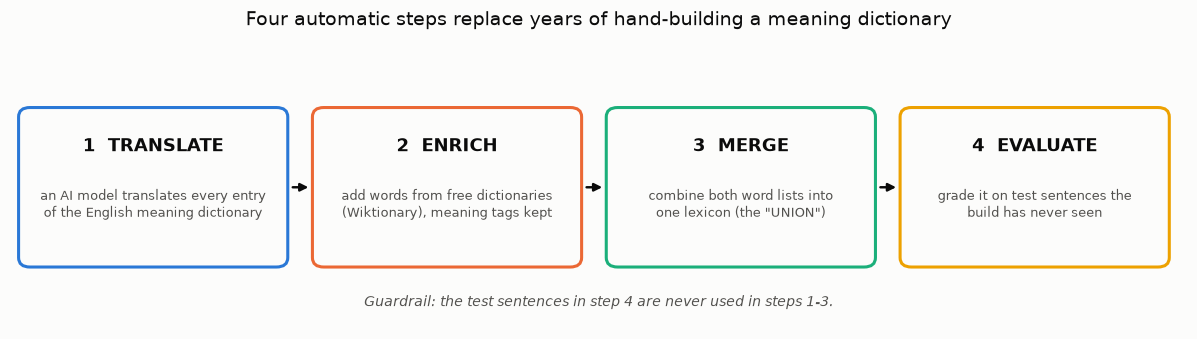

diagram only - this figure contains no measured numbers


In [2]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 12.4)
ax.set_ylim(0, 3.6)
ax.axis('off')

steps = [
    ('1  TRANSLATE', 'an AI model translates every entry\nof the English meaning dictionary', BLUE),
    ('2  ENRICH', 'add words from free dictionaries\n(Wiktionary), meaning tags kept', ORANGE),
    ('3  MERGE', 'combine both word lists into\none lexicon (the "UNION")', AQUA),
    ('4  EVALUATE', 'grade it on test sentences the\nbuild has never seen', YELLOW),
]
for i, (name, desc, color) in enumerate(steps):
    x = 0.2 + i * 3.1
    box = mpatches.FancyBboxPatch((x, 0.9), 2.6, 1.8,
                                  boxstyle='round,pad=0.12,rounding_size=0.12',
                                  facecolor=SURFACE, edgecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x + 1.3, 2.32, name, ha='center', va='center', fontsize=11.5,
            fontweight='bold', color=INK)
    ax.text(x + 1.3, 1.58, desc, ha='center', va='center', fontsize=8.8, color=MUTED)
    if i < 3:
        ax.annotate('', xy=(x + 2.97, 1.8), xytext=(x + 2.74, 1.8),
                    arrowprops=dict(arrowstyle='-|>', color=INK, linewidth=1.6))

ax.set_title('Four automatic steps replace years of hand-building a meaning dictionary',
             pad=14)
ax.text(6.2, 0.28, 'Guardrail: the test sentences in step 4 are never used in steps 1-3.',
        ha='center', fontsize=9, color=MUTED, style='italic')
plt.tight_layout()
plt.show()
print('diagram only - this figure contains no measured numbers')

## Finding 1: better translators did not help much - more words did

**Swapping in a fancier translator barely moved the results. Adding words from free,
human-curated resources - a dictionary (Wiktionary), then a wordnet - was the only
kind of step that lifted both accuracy and coverage.**

How do we know? We used Finnish as the testbed. Finnish is the one language that has
both a hand-built USAS lexicon (years of expert work, by Moore & Rayson) and
human-checked test sentences ("FIN-GOLD"). So we rebuilt Finnish the machine way, rung
by rung, and graded every rung against the human answers:

1. **Commercial MT** - an ordinary commercial translation service translates every English entry
2. **Qwen** - an open AI model does the translating instead
3. **GPT-5-mini** - a commercial AI model does it
4. **Qwen + context / multi-prompt** - the open model gets smarter instructions
5. **Qwen + Wiktionary** - the open model's list is *enriched* with words from a free dictionary
6. **+ WordNet** - a second free resource: FinnWordNet's words join via their shared
   concepts with the English WordNet (the same idea worked for Danish and Dutch)
7. **Human hand-built** - the real thing, as the reference

*(You can run this cell without reading it - it draws the ladder: accuracy on the left,
coverage on the right.)*

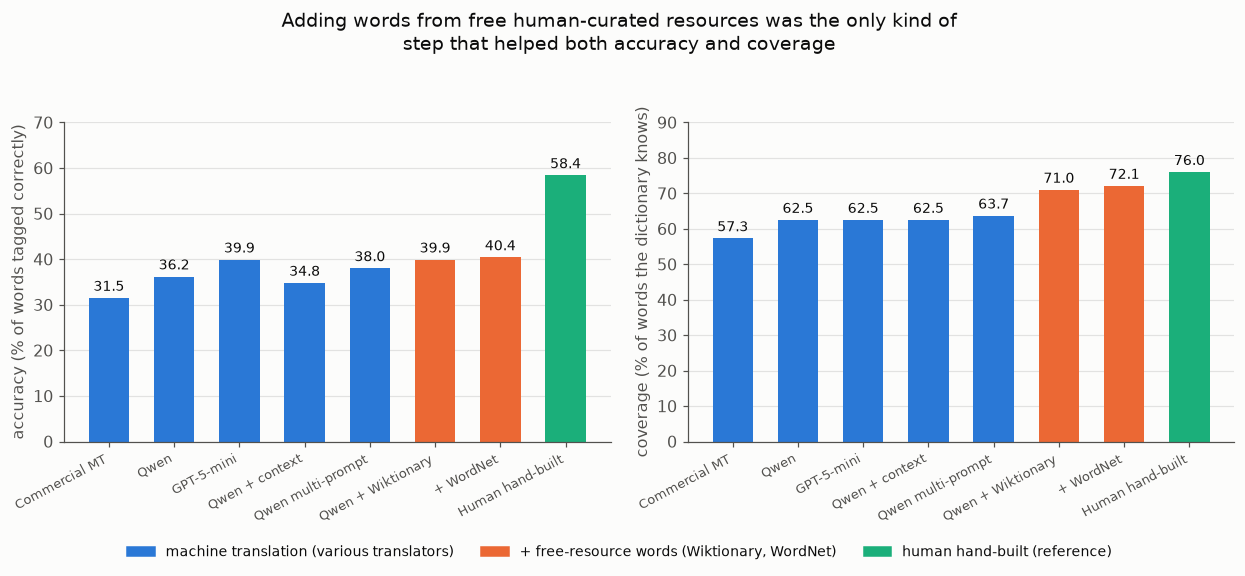

numbers loaded from results_index.json <- usas_wsd_fin_rule_fin_googletranslate.json; usas_wsd_fin_rule_fin_qwen.json; usas_wsd_fin_rule_fin_gpt-5-mini.json; usas_wsd_fin_rule_fin_qwen_ctx.json; usas_wsd_fin_rule_fin_qwen_multi.json; usas_wsd_fin_rule_fin_qwen_wiki.json; usas_wsd_fin_rule_fin_open_wn.json; published (Moore & Rayson), reproduced


In [3]:
ladder = INDEX['ladder_fin_gold']
rungs = [
    ('googletranslate', 'Commercial MT'),
    ('qwen', 'Qwen'),
    ('gpt-5-mini', 'GPT-5-mini'),
    ('qwen_ctx', 'Qwen + context'),
    ('qwen_multi', 'Qwen multi-prompt'),
    ('qwen_wiki', 'Qwen + Wiktionary'),
    ('open_wn', '+ WordNet'),
    ('manual_handbuilt', 'Human hand-built'),
]
colors = [BLUE] * 5 + [ORANGE, ORANGE, AQUA]
xs = range(len(rungs))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
panels = [(axes[0], 'acc', 'accuracy (% of words tagged correctly)', 70),
          (axes[1], 'coverage', 'coverage (% of words the dictionary knows)', 90)]
for ax, metric, ylab, top in panels:
    vals = [ladder[k][metric] for k, _ in rungs]
    bars = ax.bar(list(xs), vals, color=colors, width=0.62)
    label_bars(ax, bars)
    ax.set_xticks(list(xs))
    ax.set_xticklabels([lbl for _, lbl in rungs], fontsize=8.5,
                       rotation=28, ha='right')
    ax.set_ylabel(ylab)
    ax.set_ylim(0, top)
    ax.grid(axis='y', color=MUTED, alpha=0.15)
    ax.set_axisbelow(True)

handles = [mpatches.Patch(color=BLUE, label='machine translation (various translators)'),
           mpatches.Patch(color=ORANGE, label='+ free-resource words (Wiktionary, WordNet)'),
           mpatches.Patch(color=AQUA, label='human hand-built (reference)')]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.06), fontsize=9)
fig.suptitle('Adding words from free human-curated resources was the only kind of\n'
             'step that helped both accuracy and coverage', y=1.05)
plt.tight_layout()
plt.show()
srcs = [str(ladder[k].get('source_file') or ladder[k].get('source')) for k, _ in rungs]
show_source(*srcs)

### Why the ladder looks the way it does

- **Why translating a dictionary works at all.** When you translate a word, you
  naturally pick the translation of its most common meaning. So the "most common
  meaning first" ordering that makes the English lexicon useful survives the trip into
  the new language.
- **Why better translators plateau.** Every competent translator makes that same
  natural choice - there is nothing left for a fancier model to improve.
- **Why free-resource enrichment is different.** A native dictionary or wordnet entry
  brings its own correct meaning along with the word. Translation can only reach words
  that English points at; a Danish or Finnish resource adds words English never
  mentions. The wordnet step is smaller than the dictionary step but points the same
  way in every language tested - and for Danish it also taps DanNet, the Danish
  wordnet, whose synonyms donate their meaning tags to each other.
- **Why the clever variants backfire.** Asking the translator for many alternative
  translations pastes the English meaning-ordering onto looser and looser words:
  coverage up, correctness down. And feeding it sense context makes it overthink what
  is really a lookup task with one right answer.

**The practical consequence - and our recommendation:** build with a local,
open-weights translator plus Wiktionary and WordNet enrichment. This fully open build
measured equal to builds that used closed commercial translation services, so the
released lexicons contain nothing closed at all.

> **`MODE = "LIVE"`: rebuilding this stage yourself.** The commands below are quoted
> from `build_your_language.ipynb` / `lexicon_pipeline/` and are **not executed by this notebook**. They need API
> keys (OpenAI, Google, Anthropic) and either a local GPU or a small API budget - see
> the cost card near the end.

```bash
cd pymusas_danish/evals

# 0. CALIBRATE the committee on Finnish human gold (do this once, before any new
#    language; the agreement number is the credibility of every reference built later)
python build_llm_gold.py calibrate --language fin \
    --models anthropic:claude-fable-5 openai:gpt-5.6 google:gemini-3.1-pro

# 1. TRANSLATE the reference corpus with an INDEPENDENT family (Qwen via vLLM)
python translate_corpus.py --source results/llm_gold/coffee_eng.txt \
    --language Danish --model openai:qwen \
    --out results/llm_gold/coffee_dan_draft.txt

# 4. SCORE the Danish lexicons against the reference
python run_usas_wsd_eval.py --gold-file results/llm_gold/benedict_dan.txt \
    --language dan --system rule --spacy-model da_core_news_sm \
    --single-lexicon ../lexicons/da/semantic_lexicon_da_fixed.tsv
```

Every AI stage checkpoints per sentence, so it is safe to interrupt and rerun.

## How we grade thousands of words without human annotators

**Where three different AI families independently agree on a word's tag, they match
human experts about 85–88% of the time. Where they disagree, the majority vote is right
only about half the time.** The next cell prints the exact numbers from the results file.
That is why the *unanimous* votes, and only those, serve as the answer key for languages
that have no human-checked test sets.

The idea in plain words: three AI models from three different companies (Claude, GPT,
Gemini) each tag every word of the test sentences on their own, without seeing each
other's answers. We first *calibrated* this committee on Finnish and English - the two
languages where human-checked answers exist - by scoring every model and every
agreement class against the human labels (all 2,068 Finnish and 3,468 English tokens,
through the vendors' APIs). Two guardrails keep it honest: the model that translated the
texts (Qwen) is a fourth, separate family, so no model ever grades its own homework; and
the same three families are used for every language, so all languages are graded by the
same committee.

This committee loop is not just how we graded our own work - it is the recommended
way to evaluate any new lexicon you build with this recipe. It is reproducible offline:
`lexicon_pipeline/score_calibration_classes.py` re-scores the saved answers against the
shipped human gold without any API call.

*(You can run this cell without reading it - it prints the calibration card and draws
how often the committee is unanimous on each test set.)*


Calibration card - measured on the two languages with human-checked answers
  Finnish (2068 human-labelled words)
    one AI model alone, exact agreement with the human experts:
      fable     75.2%
      gpt56     71.4%
      gemini    69.8%
    ALL THREE families agree                69.1% of words -> 85.5% match the experts
    only TWO agree (majority vote)          26.5% of words -> 48.4% match the experts
    all differ (strongest model decides)     4.4% of words -> 46.7% match the experts
    combined reference, all classes together: 74.0%
  English (3468 human-labelled words)
    one AI model alone, exact agreement with the human experts:
      fable     81.3%
      gpt56     78.5%
      gemini    77.3%
    ALL THREE families agree                79.0% of words -> 88.2% match the experts
    only TWO agree (majority vote)          19.0% of words -> 56.2% match the experts
    all differ (strongest model decides)     2.0% of words -> 35.3% match the experts
    combined referen

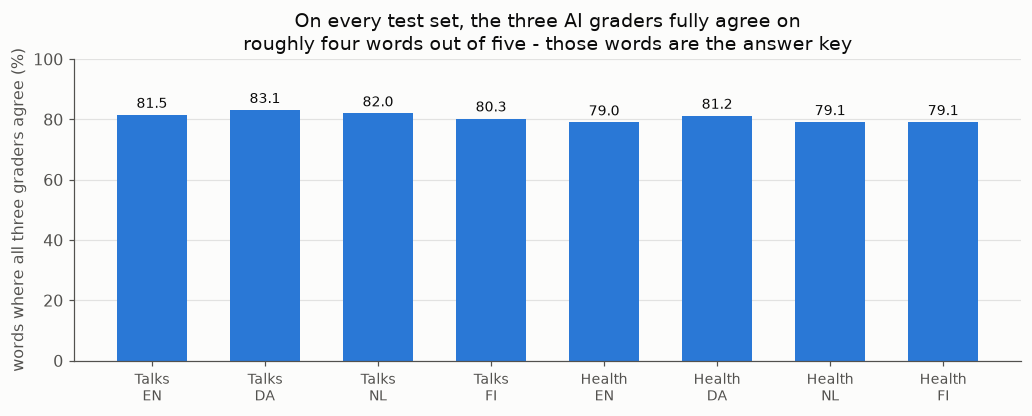

graded words per test set: between 569 and 976
numbers loaded from results_index.json <- stats_<leg>.json; evals/score_calibration_classes.py: {fable,gpt56,gemini}_calib_{fin,eng}_answers_api.json (API, 2026-08-14) vs USAS-WSD human gold; scored 2026-09-04


In [4]:
cal = INDEX['calibration']
comm = INDEX['committee_stats']

print('Calibration card - measured on the two languages with human-checked answers')
for lang, name in (('fin', 'Finnish'), ('eng', 'English')):
    c = cal[lang]
    print(f"  {name} ({c['tokens']} human-labelled words)")
    print('    one AI model alone, exact agreement with the human experts:')
    for model, v in c['single_annotator_exact_vs_gold'].items():
        print('      ' + model.ljust(10) + str(v) + '%')
    for key, label in (('unanimous', 'ALL THREE families agree'),
                       ('majority', 'only TWO agree (majority vote)'),
                       ('single_vote', 'all differ (strongest model decides)')):
        k = c['classes'][key]
        print(f"    {label.ljust(38)} {k['share_pct']:5.1f}% of words -> {k['precision_exact']}% match the experts")
    print(f"    combined reference, all classes together: {c['combined_reference_exact']}%")
ref = cal['handbuilt_lexicon_reference']
print(f"  (for scale: the hand-built Finnish lexicon scores {ref['fin']}% and the English one {ref['eng']}% on the same tests)")
print()

legs = [('convo_eng', 'Talks\nEN'), ('convo_dan', 'Talks\nDA'),
        ('convo_nld', 'Talks\nNL'), ('convo_fin', 'Talks\nFI'),
        ('health_eng', 'Health\nEN'), ('health_dan', 'Health\nDA'),
        ('health_nld', 'Health\nNL'), ('health_fin', 'Health\nFI')]
vals = [comm[k]['unanimous_pct'] for k, _ in legs]
fig, ax = plt.subplots(figsize=(9.5, 3.9))
bars = ax.bar(range(len(legs)), vals, color=BLUE, width=0.62)
label_bars(ax, bars)
ax.set_xticks(range(len(legs)))
ax.set_xticklabels([lbl for _, lbl in legs], fontsize=9)
ax.set_ylim(0, 100)
ax.set_ylabel('words where all three graders agree (%)')
ax.set_title('On every test set, the three AI graders fully agree on\n'
             'roughly four words out of five - those words are the answer key')
ax.grid(axis='y', color=MUTED, alpha=0.15)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
toks = [comm[k]['tokens'] for k, _ in legs]
print('graded words per test set: between', min(toks), 'and', max(toks))
show_source(comm['source_file'], cal['source'])


## Finding 2: the fair comparison

Two results, in plain words:

- **Our machine-built Danish and Dutch dictionaries beat the hand-built Finnish one -
  on identical text.**
- **The best setup you can actually deploy is the "hybrid": dictionary first, neural
  fallback. Look each word up in the lexicon, and only when the word is unknown, let
  a neural tagger guess.**

**Why a word list has a ceiling - and why the hybrid breaks it.** A static list can
only ever answer with a word's most usual meaning; it cannot read the sentence. The
neural tagger *does* read the sentence. Letting it handle exactly the words the list
does not know adds its flexibility where the list is blind, while keeping the list's
reliability everywhere else. (The hybrid's measured gain over the dictionary alone is
printed under the figure.)

What makes the comparison fair: the same 50 sentences - official health-agency texts
("Health") and TED-style talk transcripts ("Talks") - exist in English, Danish, Dutch
and Finnish with identical content, so every language is graded on the same material
(corpus design documented in `build_your_language.ipynb` / `lexicon_pipeline/`). A word counts as correct only
when the top tag matches exactly; punctuation is excluded. The four systems compared:

| System | What it is |
| --- | --- |
| **Hand-built** | a lexicon built by human experts (English: the original source; Dutch: an old legacy list; Finnish: Moore & Rayson's; Danish: none exists) |
| **Our pipeline** | the machine-translated + enriched lexicon from this paper (charted: the "UNION"; the released fully-open `*_open` lexicons score the same to within a few tenths - the complete grid, including the hybrid run on the current site lexicons versus ours, is the master table in `lexicons/README.md`) |
| **Neural** | a trained AI tagger that guesses a tag for every word, no dictionary at all (the multilingual "BEM" model) |
| **Hybrid** | dictionary first, neural guess only for unknown words |

*(You can run this cell without reading it - it draws one small panel per language and
text type.)*

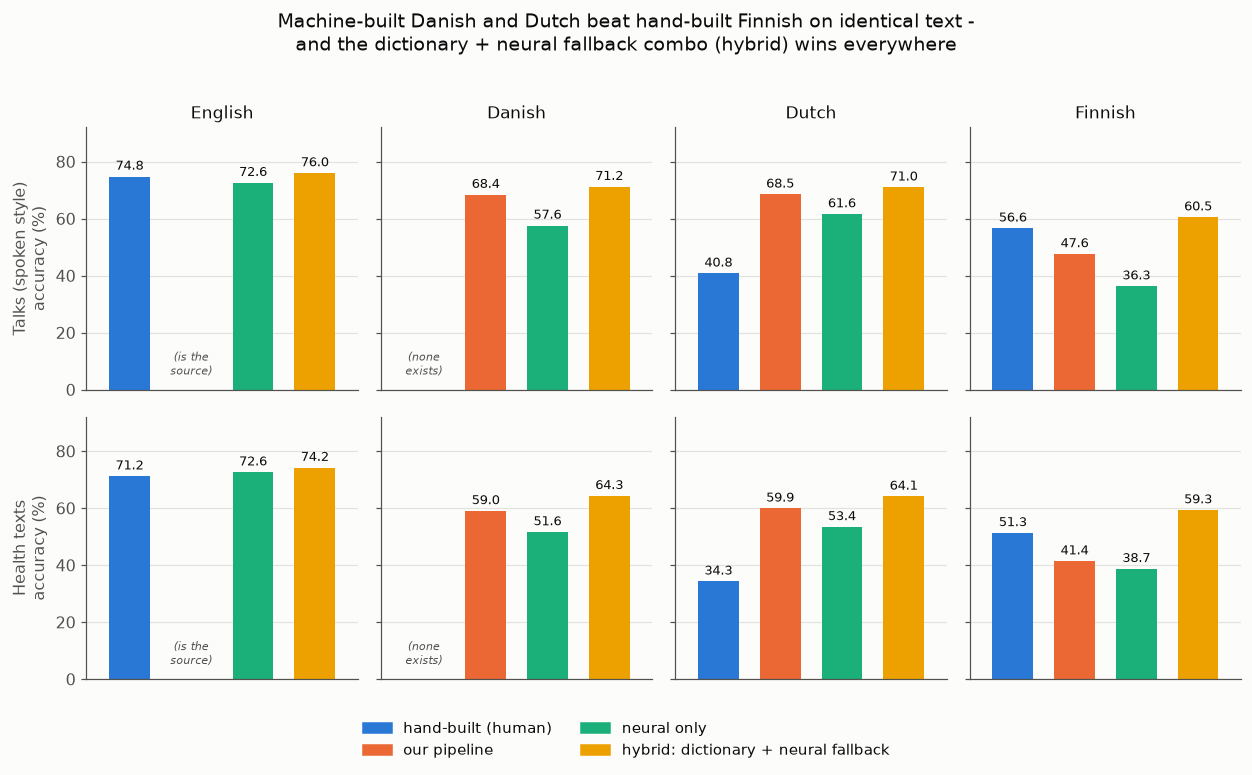

hybrid gain over the dictionary alone: from +1.2 to +8.0 accuracy points, positive on all 8 test sets
numbers loaded from results_index.json <- par_matrix_np_full.log; neural_bem_par_scores.json; hybrid_bem_par_scores.json


In [5]:
fair = INDEX['fair_comparison_rule']
bem = INDEX['bem']
hyb = INDEX['hybrid']
NEURAL = '|PyMUSAS-Neural-Multilingual-Base-BEM'

langs = [
    ('eng', 'English', 'en_handbuilt', None),
    ('dan', 'Danish', None, 'UNION'),
    ('nld', 'Dutch', 'legacy_dut', 'UNION'),
    ('fin', 'Finnish', 'fin_manual', 'fin_qwen_wiki'),
]
sys_colors = [BLUE, ORANGE, AQUA, YELLOW]
sys_names = ['hand-built (human)', 'our pipeline', 'neural only',
             'hybrid: dictionary + neural fallback']

fig, axes = plt.subplots(2, 4, figsize=(11.5, 6.2), sharey=True)
regs = [('convo', 'Talks (spoken style)'), ('health', 'Health texts')]
for row, (reg, reg_name) in enumerate(regs):
    for col, (code, lang_name, hb_key, pipe_key) in enumerate(langs):
        ax = axes[row][col]
        leg = reg + '_' + code
        vals = [fair[leg][hb_key]['acc'] if hb_key else None,
                fair[leg][pipe_key]['acc'] if pipe_key else None,
                round(100 * bem[leg + NEURAL]['acc'], 1),
                round(100 * hyb[leg]['hybrid_acc'], 1)]
        for x, (v, c) in enumerate(zip(vals, sys_colors)):
            if v is None:
                note = '(is the\nsource)' if code == 'eng' else '(none\nexists)'
                ax.text(x, 4, note, ha='center', va='bottom', fontsize=7.3,
                        color=MUTED, style='italic')
            else:
                b = ax.bar([x], [v], color=c, width=0.66)
                label_bars(ax, b, fs=8.2)
        ax.set_xlim(-0.7, 3.7)
        ax.set_ylim(0, 92)
        ax.set_xticks([])
        if row == 0:
            ax.set_title(lang_name, fontsize=11)
        if col == 0:
            ax.set_ylabel(reg_name + '\naccuracy (%)')
        ax.grid(axis='y', color=MUTED, alpha=0.15)
        ax.set_axisbelow(True)

handles = [mpatches.Patch(color=c, label=n) for c, n in zip(sys_colors, sys_names)]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.095), fontsize=9.5)
fig.suptitle('Machine-built Danish and Dutch beat hand-built Finnish on identical text -\n'
             'and the dictionary + neural fallback combo (hybrid) wins everywhere', y=1.02)
plt.tight_layout()
plt.show()
gains = sorted(round(100 * (v['hybrid_acc'] - v['rule_acc']), 1)
               for k, v in hyb.items() if k != 'source_file')
print('hybrid gain over the dictionary alone: from +' + str(gains[0]) + ' to +'
      + str(gains[-1]) + ' accuracy points, positive on all 8 test sets')
show_source(fair['source_file'], bem['source_file'], hyb['source_file'])

> **`MODE = "LIVE"`: rebuilding the fair comparison.** Commands quoted from
> `build_your_language.ipynb` / `lexicon_pipeline/`, never executed by this notebook.

```bash
cd pymusas_danish/evals

# 1. build the two 50-sentence equal-content corpora in en/da/nl/fi
#    (downloads six OPUS archives into --workdir; deterministic, seed 20260813)
python ../scripts/build_par_corpora.py --workdir /tmp/opus_par \
    --out-dir results/llm_gold --tokens

# 2. committee annotation: run_api_annotators.py once per AI family per test set
#    (see the loop in REPRODUCE.md), then merge with build_llm_gold.py build

# 3. score every system on every language
bash score_par_matrix.sh          # dictionary (rule) systems
python run_neural_bem_par.py      # neural systems
python run_hybrid_bem_par.py      # hybrid: dictionary + neural fallback
```

## Where the remaining mistakes come from

**Different languages need different fixes: Finnish's dictionary is mostly missing
words, while Danish and Dutch mostly know the word but pick the wrong meaning.**

Every mistake a dictionary system makes is one of two kinds:

- **has never seen the word** - the word is not in the lexicon at all. That share is
  100 minus coverage;
- **knows the word, picks the wrong meaning** - the word is in the lexicon, but the
  tagger chooses the wrong one of its listed meanings. That share is coverage minus
  accuracy.

**Why Finnish looks hard.** Finnish glues its grammar onto the word itself, so the
same word shows up in many shapes the dictionary does not recognize. That *hides*
words from the dictionary - a coverage problem, not a meaning problem. Finnish
meanings are not harder to pick: the figure shows Finnish has the *lowest*
wrong-meaning share of the four languages.

This diagnosis is also the recommended way to decide what to improve next in your own
language: read off which of the two error kinds dominates, and pull that lever.

*(You can run this cell without reading it - it draws the two error kinds stacked per
language.)*

A point worth pausing on: Finnish is not "harder to understand" for the dictionary —
of the four languages it actually has the *lowest* wrong-meaning rate on the words it
knows. Its problem is that Finnish grammar glues words together and changes their
endings, which *hides* words from a dictionary lookup. That is why the fix for
Finnish is a better lookup — the "plot twist" section below shows that a
morphological analyzer recovers most of the hidden words in one stroke — while the
fix for English is better meaning-ordering. The diagnosis, not the language's
reputation, picks the remedy.

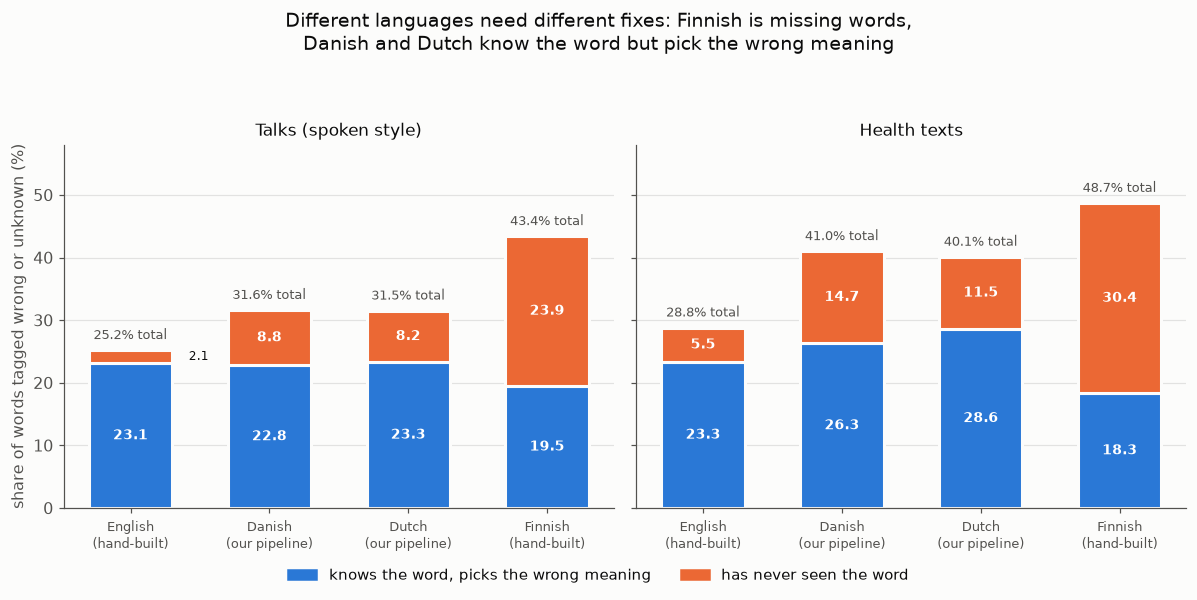

numbers loaded from results_index.json <- par_matrix_np_full.log; no-entry = 100 - coverage; wrong-sense = coverage - accuracy


In [6]:
fair = INDEX['fair_comparison_rule']
picks = [
    ('eng', 'English\n(hand-built)', 'en_handbuilt'),
    ('dan', 'Danish\n(our pipeline)', 'UNION'),
    ('nld', 'Dutch\n(our pipeline)', 'UNION'),
    ('fin', 'Finnish\n(hand-built)', 'fin_manual'),
]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
for ax, (reg, reg_name) in zip(axes, [('convo', 'Talks (spoken style)'),
                                      ('health', 'Health texts')]):
    wrong, missing = [], []
    for code, _, key in picks:
        r = fair[reg + '_' + code][key]
        missing.append(round(100 - r['coverage'], 1))
        wrong.append(round(r['coverage'] - r['acc'], 1))
    xs = range(len(picks))
    ax.bar(list(xs), wrong, color=BLUE, width=0.6, edgecolor=SURFACE, linewidth=2)
    ax.bar(list(xs), missing, bottom=wrong, color=ORANGE, width=0.6,
           edgecolor=SURFACE, linewidth=2)
    for x in xs:
        total = round(wrong[x] + missing[x], 1)
        ax.text(x, total + 1.3, '{:.1f}% total'.format(total),
                ha='center', va='bottom', fontsize=8.3, color=MUTED)
        for h, base in [(wrong[x], 0), (missing[x], wrong[x])]:
            if h >= 5:
                ax.text(x, base + h / 2, '{:.1f}'.format(h), ha='center',
                        va='center', fontsize=9, color='#ffffff', fontweight='bold')
            else:
                ax.text(x + 0.42, base + h / 2, '{:.1f}'.format(h), ha='left',
                        va='center', fontsize=8, color=INK)
    ax.set_xticks(list(xs))
    ax.set_xticklabels([name for _, name, _ in picks], fontsize=8.8)
    ax.set_title(reg_name, fontsize=11)
    ax.set_ylim(0, 58)
    ax.grid(axis='y', color=MUTED, alpha=0.15)
    ax.set_axisbelow(True)
axes[0].set_ylabel('share of words tagged wrong or unknown (%)')
handles = [mpatches.Patch(color=BLUE, label='knows the word, picks the wrong meaning'),
           mpatches.Patch(color=ORANGE, label='has never seen the word')]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.05), fontsize=9.5)
fig.suptitle('Different languages need different fixes: Finnish is missing words,\n'
             'Danish and Dutch know the word but pick the wrong meaning', y=1.06)
plt.tight_layout()
plt.show()
show_source(fair['source_file'],
            'no-entry = 100 - coverage; wrong-sense = coverage - accuracy')

## A closer look at Danish's unknown words

**Most words the Danish dictionary does not know are just glued-together words it does
know.**

Danish, like German and Dutch, writes compounds as a single word. Take
*blodforgiftning*: it is *blod* (blood) + *forgiftning* (poisoning) - "blood
poisoning", the everyday word for sepsis. Our lexicon knows both halves but has never
seen the glued word, so it counts as unknown. We autopsied every unknown word ("OOV",
out of vocabulary) in the Danish test sets and sorted them into three piles:

- **glued-together compounds** - split them and the parts are already known;
- **known word, different form** - a plural, past tense or similar form of a known word;
- **genuinely new** - names, places, foreign terms, abbreviations.

*(You can run this cell without reading it - it draws the three piles and prints real
examples.)*

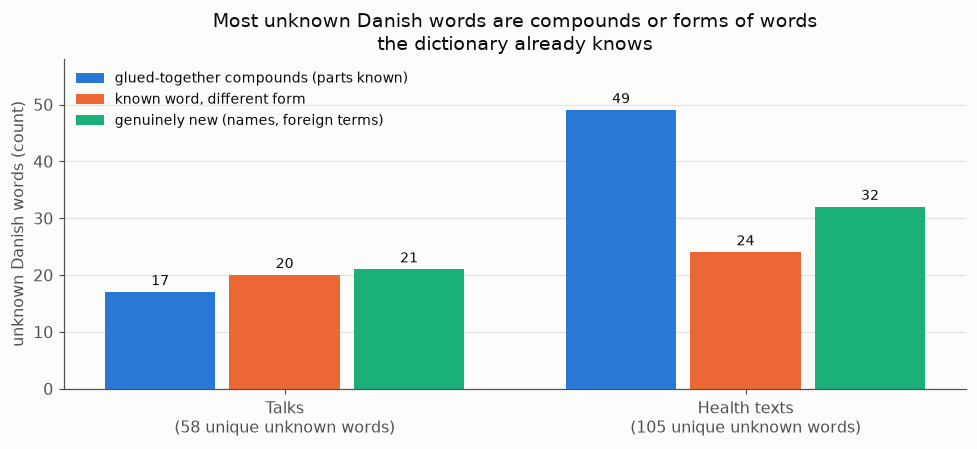

compound examples (health): blodforgiftning, denguefeber, biosikkerhed, bakteriesygdomme
  e.g. blodforgiftning = blod + forgiftning = 'blood poisoning' (sepsis)
compound examples (talks): holdfølelse, hurtigopkald, kropsmasse
genuinely new examples: chimpanserne, Etiopien, 80'erne, ECDC, Clostridium difficile, Caribien
numbers loaded from results_index.json <- evals/oov_autopsy.py run 2026-08-14


In [7]:
oov = INDEX['oov_autopsy_dan']
cats = [('compound_recoverable', 'glued-together compounds (parts known)', BLUE),
        ('inflection_recoverable', 'known word, different form', ORANGE),
        ('residual', 'genuinely new (names, foreign terms)', AQUA)]
regs = [('convo', 'Talks'), ('health', 'Health texts')]

fig, ax = plt.subplots(figsize=(9, 4.2))
width = 0.24
for j, (key, lbl, color) in enumerate(cats):
    xs = [i + (j - 1) * (width + 0.03) for i in range(len(regs))]
    vals = [oov[r][key] for r, _ in regs]
    bars = ax.bar(xs, vals, width=width, color=color, label=lbl)
    label_bars(ax, bars, fmt='{:.0f}')
ax.set_xticks(range(len(regs)))
ax.set_xticklabels([n + '\n(' + str(oov[r]['unique']) + ' unique unknown words)'
                    for r, n in regs])
ax.set_ylabel('unknown Danish words (count)')
ax.set_ylim(0, 58)
ax.set_title('Most unknown Danish words are compounds or forms of words\n'
             'the dictionary already knows')
ax.legend(frameon=False, fontsize=9)
ax.grid(axis='y', color=MUTED, alpha=0.15)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

ex_h = oov['health']['compound_examples']
print('compound examples (health):', ', '.join(ex_h))
print('  e.g. ' + ex_h[0] + " = blod + forgiftning = 'blood poisoning' (sepsis)")
print('compound examples (talks):', ', '.join(oov['convo']['compound_examples']))
print('genuinely new examples:',
      ', '.join(oov['convo']['residual_examples'] + oov['health']['residual_examples']))
show_source(oov['source'])

## An honest result: the compound-expansion pilot

**Finding the missing compound words is easy. Guessing their meaning tag without
reading the sentence is not.**

Since most unknown Danish words are compounds, we tried the obvious fix: split
compounds automatically, look up the parts, and add the glued word to the lexicon with
the parts' tags (the "expanded" lexicon, `UNION_exp`). Coverage rose clearly - the
words are found. But accuracy barely moved: a word seen in isolation often has several
defensible tags, and without reading the sentence the expansion frequently attaches a
plausible-but-wrong one.

**Why the mechanical guess fails where the neural fallback works.** The expansion tags
a glued word by looking only at its parts - like any static list, it answers with the
most usual meaning and cannot read the sentence. The hybrid's neural fallback *does*
read the sentence, which is why it turns unknown words into correct tags at a much
higher rate; the measured conversion rates for both are printed under the next figure.

*(You can run this cell without reading it - it draws before/after bars for coverage
and accuracy.)*

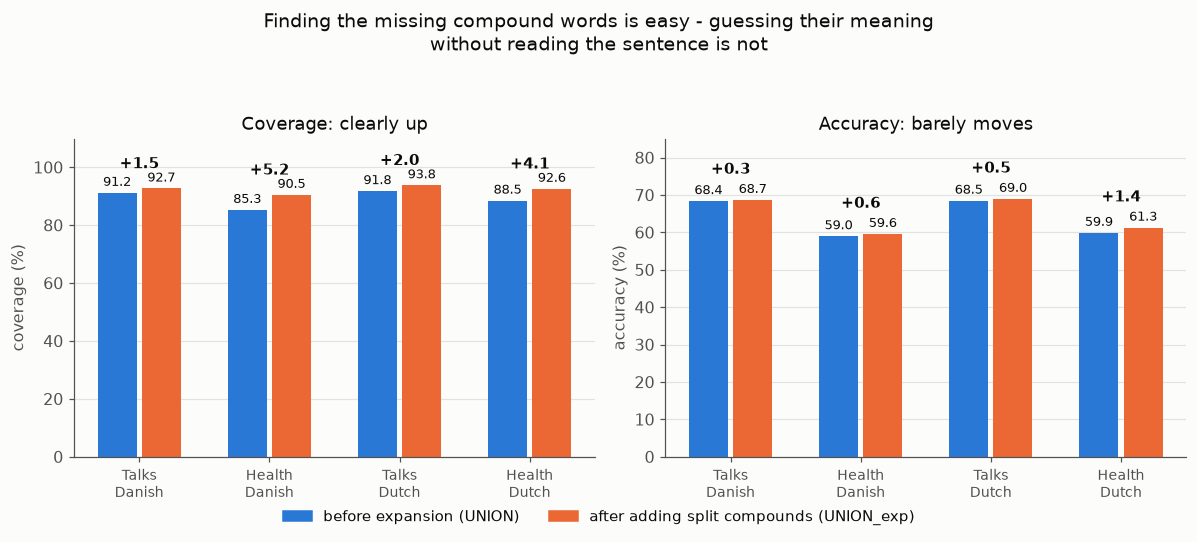

share of newly covered words that get the CORRECT tag (Danish test sets):
  Talks   mechanical expansion: 20%   sentence-reading fallback: 32%   (1.6x better)
  Health  mechanical expansion: 12%   sentence-reading fallback: 36%   (3.1x better)
numbers loaded from results_index.json <- par_matrix_np_full.log; hybrid_bem_par_scores.json


In [8]:
fair = INDEX['fair_comparison_rule']
legs = [('convo_dan', 'Talks\nDanish'), ('health_dan', 'Health\nDanish'),
        ('convo_nld', 'Talks\nDutch'), ('health_nld', 'Health\nDutch')]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
panels = [(axes[0], 'coverage', 'Coverage: clearly up', 'coverage (%)'),
          (axes[1], 'acc', 'Accuracy: barely moves', 'accuracy (%)')]
for ax, metric, title, ylab in panels:
    before = [fair[k]['UNION'][metric] for k, _ in legs]
    after = [fair[k]['UNION_exp'][metric] for k, _ in legs]
    xs = range(len(legs))
    b1 = ax.bar([x - 0.17 for x in xs], before, width=0.3, color=BLUE)
    b2 = ax.bar([x + 0.17 for x in xs], after, width=0.3, color=ORANGE)
    label_bars(ax, b1, fs=8.3)
    label_bars(ax, b2, fs=8.3)
    for x in xs:
        d = after[x] - before[x]
        ax.text(x, max(before[x], after[x]) + 7, '+{:.1f}'.format(d),
                ha='center', fontsize=10, color=INK, fontweight='bold')
    ax.set_xticks(list(xs))
    ax.set_xticklabels([lbl for _, lbl in legs], fontsize=9)
    ax.set_title(title, fontsize=11.5)
    ax.set_ylabel(ylab)
    ax.set_ylim(0, max(max(before), max(after)) + 16)
    ax.grid(axis='y', color=MUTED, alpha=0.15)
    ax.set_axisbelow(True)

handles = [mpatches.Patch(color=BLUE, label='before expansion (UNION)'),
           mpatches.Patch(color=ORANGE, label='after adding split compounds (UNION_exp)')]
fig.legend(handles=handles, loc='lower center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.04), fontsize=9.5)
fig.suptitle('Finding the missing compound words is easy - guessing their meaning\n'
             'without reading the sentence is not', y=1.05)
plt.tight_layout()
plt.show()

# Of the newly covered words, how many become CORRECT tags?
# Mechanical expansion vs the hybrid's sentence-reading neural fallback (Danish).
hyb = INDEX['hybrid']
print('share of newly covered words that get the CORRECT tag (Danish test sets):')
for leg, name in [('convo_dan', 'Talks'), ('health_dan', 'Health')]:
    exp_gain = fair[leg]['UNION_exp']['acc'] - fair[leg]['UNION']['acc']
    exp_cov = fair[leg]['UNION_exp']['coverage'] - fair[leg]['UNION']['coverage']
    h = hyb[leg]
    bem_gain = 100 * (h['hybrid_acc'] - h['rule_acc'])
    bem_fill = 100.0 * h['bem_filled'] / h['n']
    exp_rate = 100 * exp_gain / exp_cov
    bem_rate = 100 * bem_gain / bem_fill
    print('  ' + name.ljust(8)
          + 'mechanical expansion: {:.0f}%'.format(exp_rate)
          + '   sentence-reading fallback: {:.0f}%'.format(bem_rate)
          + '   ({:.1f}x better)'.format(bem_rate / exp_rate))
show_source(fair['source_file'], hyb['source_file'])

## The Finnish plot twist: the dictionary knew the words all along

**The biggest single improvement in the whole project came from a tool that adds
zero words to any dictionary.**

Finnish looked like the hard language: its dictionary systems scored 15–20 points
below the Germanic ones, and the diagnosis said "missing words". But a closer look
showed something subtler: many "missing" words *were* in the dictionary — under
their base form. Finnish grammar changes word endings so much that the standard
word-form matcher (the spaCy lemmatizer) often fails to connect an inflected word
in the text to its dictionary entry. The dictionary was fine; the *lookup* was
failing.

The fix is a **morphological analyzer** — a classical, rule-based tool
(GiellaLT/HFST, free and open) that knows Finnish grammar exhaustively and can
reduce any word form to its base form. We bolted it on as a fallback: only when
the normal lookup finds nothing, ask the analyzer for the base form and try again.
Nothing else changes; no test data is involved.

The result, on the human-checked Finnish test set: the hand-built dictionary
system jumps from **58.4 to 73.8** correct — a bigger gain than every other
improvement in this notebook combined, landing Finnish in the same range as
English. With the neural fallback stacked behind it: **74.8**. And a neat
control: switching to a larger spaCy model also helps (+4.6) — but with the
analyzer in place, model size stops mattering entirely. The moral: for languages
with rich word grammar, don't blame the dictionary — fix the lookup. (Commands:
the morphological-analyzer fallback script in the working repository; numbers in
its log.)

## Add your language

Everything in this pipeline is free or cheap, and nothing in it is specific to Danish
or Dutch. **To actually build one, open [`build_your_language.ipynb`](build_your_language.ipynb)** —
the same six stages as runnable cells, calling the scripts in `lexicon_pipeline/`.
The checker below tests the two prerequisites for a new language:

1. a **spaCy model** - a free grammar analyzer that splits sentences into words and
   base forms; most European languages have one;
2. the **OPUS parallel texts** - free public collections of translated sentences
   (TED2020 talks and ECDC health texts) from which the fair test sets are built.

It then prints a **cost card**: what the paid-or-slow stages cost. The URL check needs
internet; if you are offline it says so and carries on.

*(You can run this cell - it checks German as a demo. Edit the last line to try your
own language.)*

In [9]:
import importlib.util
import urllib.request

OPUS_URLS = {
    'TED2020 (talks)': 'https://object.pouta.csc.fi/OPUS-TED2020/v1/moses/PAIR.txt.zip',
    'ECDC (health)': 'https://object.pouta.csc.fi/OPUS-ECDC/v2016-03-16/moses/PAIR.txt.zip',
}

def check_language(iso2, iso3, spacy_model):
    '''Readiness check + cost card for adding a new language to the pipeline.'''
    print('Readiness check for language:', iso2, '/', iso3)
    # (a) is the spaCy model installed?
    if importlib.util.find_spec(spacy_model) is not None:
        print('  [ok] spaCy model', spacy_model, 'is installed')
    else:
        print('  [--] spaCy model', spacy_model, 'is NOT installed')
        print('       fix: pip install spacy && python -m spacy download ' + spacy_model)
    # (b) are the OPUS parallel texts available for this language paired with English?
    pair = '-'.join(sorted([iso2, 'en']))
    for name, tmpl in OPUS_URLS.items():
        url = tmpl.replace('PAIR', pair)
        try:
            req = urllib.request.Request(url, method='HEAD',
                                         headers={'User-Agent': 'add-your-language-notebook'})
            with urllib.request.urlopen(req, timeout=12):
                pass
            print('  [ok] OPUS', name, 'has the', pair, 'pair:', url)
        except Exception as err:
            print('  [--] OPUS', name, 'not available or unreachable',
                  '(' + type(err).__name__ + ')')
            if 'TED2020' in name:
                print('       if it is really missing for your language: use ECDC only')
    # (c) the cost card
    print()
    print('  Cost card (measured on our Danish/Dutch runs, August 2026 list prices; per new language)')
    print('    1. committee reference    ~3,300-word text x 3 API families: about $13; plus translation')
    print('       and two-family post-edit of that text: about $5. Total ~$20, under an hour.')
    print('       (Claude $10/$50, GPT-5.6 $4/$20, Gemini 3.1 Pro $2/$12 per million tokens in/out)')
    print('    2. translation stream     local open-weights model (Qwen via Ollama): free, ~2 h on one GPU')
    print('       for the 54k-entry list | via an API instead: roughly $5-15')
    print('    3. enrichment + repair    free - Wiktionary and WordNet downloads, CPU minutes')
    print('    4. scoring                free - CPU minutes on a laptop, no API')
    print('  pipeline language code:', iso3, '| OPUS pair:', pair)

# Demo: German. Edit this line to try your language.
check_language('de', 'deu', 'de_core_news_sm')

Readiness check for language: de / deu
  [--] spaCy model de_core_news_sm is NOT installed
       fix: pip install spacy && python -m spacy download de_core_news_sm


  [ok] OPUS TED2020 (talks) has the de-en pair: https://object.pouta.csc.fi/OPUS-TED2020/v1/moses/de-en.txt.zip
  [ok] OPUS ECDC (health) has the de-en pair: https://object.pouta.csc.fi/OPUS-ECDC/v2016-03-16/moses/de-en.txt.zip

  Cost card (measured on our Danish/Dutch runs, August 2026 list prices; per new language)
    1. committee reference    ~3,300-word text x 3 API families: about $13; plus translation
       and two-family post-edit of that text: about $5. Total ~$20, under an hour.
       (Claude $10/$50, GPT-5.6 $4/$20, Gemini 3.1 Pro $2/$12 per million tokens in/out)
    2. translation stream     local open-weights model (Qwen via Ollama): free, ~2 h on one GPU
       for the 54k-entry list | via an API instead: roughly $5-15
    3. enrichment + repair    free - Wiktionary and WordNet downloads, CPU minutes
    4. scoring                free - CPU minutes on a laptop, no API
  pipeline language code: deu | OPUS pair: de-en


## Guardrails that must never be relaxed

- **Never harvest words from the test sentences.** New domain words may be collected
  from held-out text, but the test text must stay unseen by every construction step,
  or the grades mean nothing.
- **The same three AI families grade every language and every test set** - otherwise
  scores are not comparable across languages.
- **No model grades its own homework**: the translator family is never a committee
  member, and no committee family edits text it later annotates.

Where to go next: [`build_your_language.ipynb`](build_your_language.ipynb) (the recipe as
runnable steps), `lexicon_pipeline/` (the scripts behind each step), and
[`lexicons/README.md`](lexicons/README.md) (the released Danish and Dutch dictionaries and
their scores).

> ## The recommended way to do it today
>
> 1. **Build fully open-source.** Translate the English lexicon with a local,
>    open-weights model (we used Qwen), then enrich it twice: with Wiktionary words,
>    and with the language's wordnet (via shared concepts with the English WordNet).
>    The fully open build measured equal-or-better than builds using closed
>    translation services, so nothing closed is needed - the released `*_open`
>    lexicons are exactly this build. (One caution, measured: if a language already
>    has a strong hand-built lexicon, enrich it only with words it has never seen
>    in any form - naive additions can override better native entries.)
> 2. **Merge** all word lists into one lexicon (existing entries always win; new
>    sources only add).
> 3. **Deploy as the hybrid.** Dictionary first, neural (BEM) fallback only for
>    unknown words - the best architecture in our measurements. For languages with
>    rich word grammar (Finnish-style), add the **morphological-analyzer fallback**
>    before the neural one: it was worth +15 points for Finnish and makes the
>    choice of spaCy model irrelevant.
> 4. **Evaluate with the committee loop.** Three AI model families tag independently,
>    unanimous votes are the reference, and the committee is calibrated on Finnish
>    human gold first.
> 5. **Extend by diagnosis.** Let the error decomposition and the unknown-word autopsy
>    tell you which lever your language needs: more words, better meaning-picking -
>    or, before either, a better lookup. Harvest new domain words only from held-out
>    text - never from test sentences.

*(You can run the last cell without reading it - it prints where every number in this
notebook came from.)*

In [10]:
print('Every number in this notebook was loaded from results_index.json - none typed by hand.')
print('index compiled:', INDEX['compiled_utc'])
print()
print('section -> measurement source')
for section in ['fair_comparison_rule', 'committee_stats', 'bem', 'hybrid',
                'oov_autopsy_dan', 'calibration']:
    src = INDEX[section].get('source_file') or INDEX[section].get('source')
    print(' ', section.ljust(22), src)
rung_sources = sorted({str(v.get('source_file', v.get('source')))
                       for v in INDEX['ladder_fin_gold'].values()})
print(' ', 'ladder_fin_gold'.ljust(22), '; '.join(rung_sources))

Every number in this notebook was loaded from results_index.json - none typed by hand.
index compiled: 2026-09-04T10:12:08.816372+00:00

section -> measurement source
  fair_comparison_rule   par_matrix_np_full.log
  committee_stats        stats_<leg>.json
  bem                    neural_bem_par_scores.json
  hybrid                 hybrid_bem_par_scores.json
  oov_autopsy_dan        evals/oov_autopsy.py run 2026-08-14
  calibration            evals/score_calibration_classes.py: {fable,gpt56,gemini}_calib_{fin,eng}_answers_api.json (API, 2026-08-14) vs USAS-WSD human gold; scored 2026-09-04
  ladder_fin_gold        published (Moore & Rayson), reproduced; usas_wsd_fin_rule_fin_googletranslate.json; usas_wsd_fin_rule_fin_gpt-5-mini.json; usas_wsd_fin_rule_fin_open_wn.json; usas_wsd_fin_rule_fin_open_wn_exp.json; usas_wsd_fin_rule_fin_qwen.json; usas_wsd_fin_rule_fin_qwen_ctx.json; usas_wsd_fin_rule_fin_qwen_multi.json; usas_wsd_fin_rule_fin_qwen_wiki.json; usas_wsd_fin_rule_fin_site.json;